# Lab 5: Panorama Stitching [100 Points]

Today we will stitch two images together to create a panorama!


## Step 0: Setup [0 Points]

First, we need to import the necessary libraries and load our images.
For this assignment, we need two images that have some overlap.
We'll download two images for you (the images are from [here](https://github.com/stanleyedward/panorama-image-stitching)).

In [ ]:
!wget https://raw.githubusercontent.com/stanleyedward/panorama-image-stitching/refs/heads/main/inputs/front/front_01.jpeg
!wget https://raw.githubusercontent.com/stanleyedward/panorama-image-stitching/refs/heads/main/inputs/front/front_02.jpeg
!mv front_01.jpeg image_left.jpeg
!mv front_02.jpeg image_right.jpeg

--2025-10-13 22:54:52--  https://raw.githubusercontent.com/stanleyedward/panorama-image-stitching/refs/heads/main/inputs/front/front_01.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 235076 (230K) [image/jpeg]
Saving to: ‘front_01.jpeg’

front_01.jpeg       100%[===================>] 229.57K  --.-KB/s    in 0.03s   

2025-10-13 22:54:52 (8.39 MB/s) - ‘front_01.jpeg’ saved [235076/235076]

--2025-10-13 22:54:52--  https://raw.githubusercontent.com/stanleyedward/panorama-image-stitching/refs/heads/main/inputs/front/front_02.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP

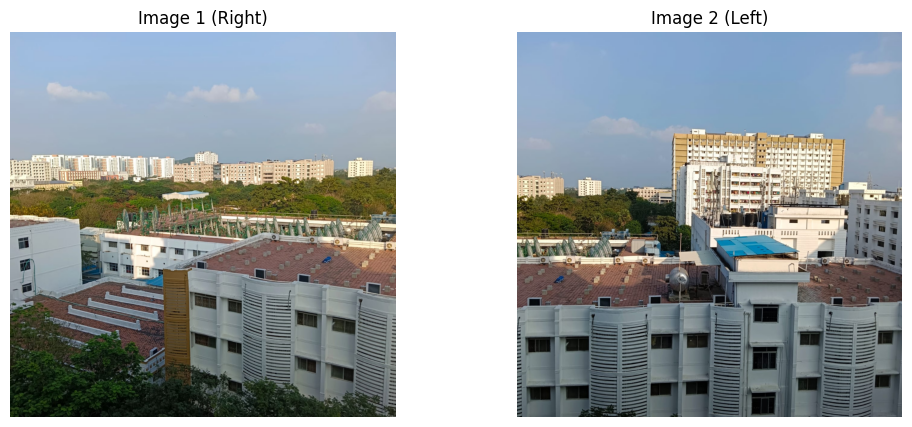

In [ ]:
import requests
import os
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm


# Read the two images and convert to grayscale
img1 = cv2.cvtColor(cv2.imread("image_left.jpeg"), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread("image_right.jpeg"), cv2.COLOR_BGR2RGB)

# Convert to grayscale
img1_gray = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

# Plot them (non grayscale when plotting because it looks nicer)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(img1); ax1.set_title('Image 1 (Right)'); ax1.axis('off')
ax2.imshow(img2); ax2.set_title('Image 2 (Left)'); ax2.axis('off')
plt.show()

## Step 1: Find Keypoints and Descriptors [0 Points]

The first step in stitching is to find points of interest that are distinctive in both images.
We use the [SIFT (Scale-Invariant Feature Transform)](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html) algorithm for this.
SIFT finds keypoints and computes a descriptor for each one.
The descriptor is a vector that describes the image patch around the keypoint, making it possible to match keypoints between images.
The idea is that two similar keypoints should have similar descriptors.

We will provide this part of the code for you.
You can also see a visualization of the keypoints below (for fun), once you run this cell.

Found 12581 keypoints in Image 1 and 10173 keypoints in Image 2.
Descriptor shape for Image 1: (12581, 128)
Descriptor shape for Image 2: (10173, 128)


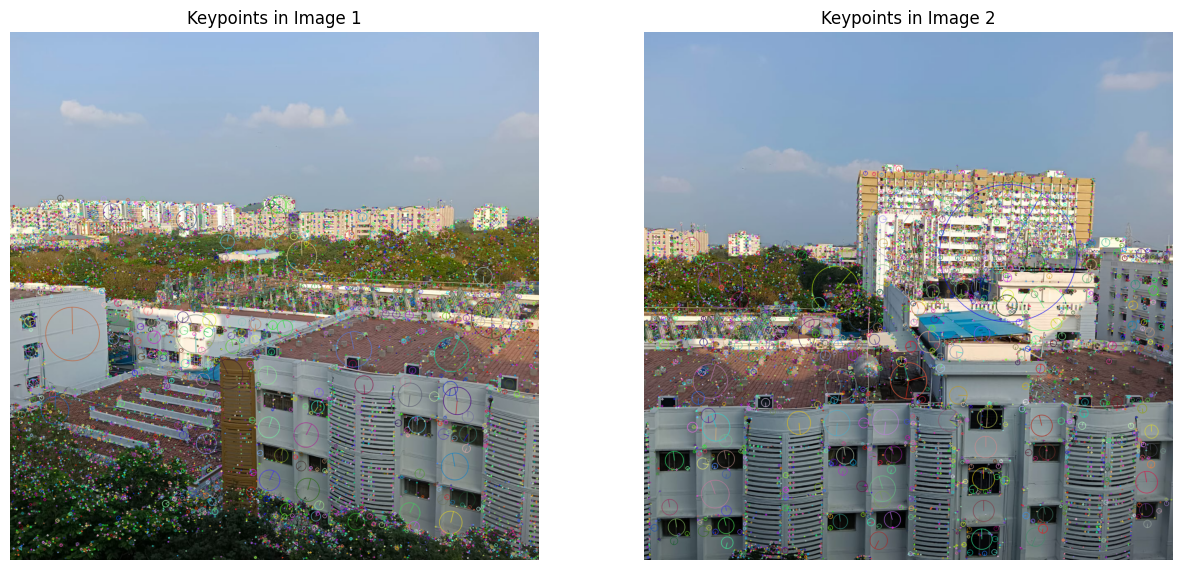

In [ ]:
# Initialize SIFT detector
sift = cv2.SIFT_create()

# Find keypoints and descriptors

# !IMPORTANT! -- YOU WILL USE THESE
# !IMPORTANT! -- YOU WILL USE THESE
# !IMPORTANT! -- YOU WILL USE THESE
kp1, des1 = sift.detectAndCompute(img1_gray, None)  # keypoint, descriptor of image 1 (left)
kp2, des2 = sift.detectAndCompute(img2_gray, None)  # keypoint, descriptor of image 2 (right)
# !IMPORTANT! -- YOU WILL USE THESE
# !IMPORTANT! -- YOU WILL USE THESE
# !IMPORTANT! -- YOU WILL USE THESE

print(f"Found {len(kp1)} keypoints in Image 1 and {len(kp2)} keypoints in Image 2.")
print(f"Descriptor shape for Image 1: {des1.shape}")
print(f"Descriptor shape for Image 2: {des2.shape}")

# Visualize the keypoints
# The flags ensure that the size and orientation of the keypoints are drawn
img1_keypoints = cv2.drawKeypoints(img1, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img2_keypoints = cv2.drawKeypoints(img2, kp2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Plot the images with keypoints
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
ax1.imshow(img1_keypoints)
ax1.set_title('Keypoints in Image 1')
ax1.axis('off')
ax2.imshow(img2_keypoints)
ax2.set_title('Keypoints in Image 2')
ax2.axis('off')
plt.show()

## Step 2: Custom Feature Matching & Filtering [75 Points]

Now, you will implement a feature matcher from scratch.
The goal is to find corresponding keypoints by comparing their descriptors.
For each descriptor in `des1`, you must find the **two** most similar descriptors in `des2`.
**`des1` and `des2` are computed in the previous cell.**
We will use the Euclidean distance (L2 norm) as the similarity metric.

After finding the two best matches, you will apply [Lowe's Ratio Test](https://stackoverflow.com/questions/51197091/how-does-the-lowes-ratio-test-work) to decide if the match is good.
A match is good if the distance to the best match is significantly smaller than the distance to the second-best match.


---


Your Task:
Complete the loop below. For each descriptor `d1` in `des1`:

1. Calculate the distance between `d1` and every descriptor `d2` in `des2`.

2. Find the indices of the two descriptors in `des2` with the smallest distances to `d1`.

3. Apply the ratio test: `distance_best / distance_second_best < ratio_thresh`.

If the test passes, store the pair of indices
```
(index of d1 in des1, index of the best match in des2)
```
as a tuple in the `good_matches` list.


---


You may want to use the following functions:
- [`np.linalg.norm`](https://numpy.org/doc/2.3/reference/generated/numpy.linalg.norm.html)
- [`np.argsort`](https://numpy.org/devdocs/reference/generated/numpy.argsort.html)



In [ ]:
from typing import List, Tuple

good_matches: List[Tuple[int, int]] = []
ratio_thresh = 0.75

# TODO: Implement brute-force matching and Lowe's ratio test.
# We have written the starter loop for you.
# Once completed, this code cell may take a while to run, that is OK.
for i, d1 in enumerate(des1):
  # Compute L2 distances to all descriptors in des2
  dists = np.linalg.norm(des2 - d1, axis=1)
  # Indices of two best (smallest) distances
  idx_sorted = np.argsort(dists)
  j1, j2 = idx_sorted[0], idx_sorted[1]
  best, second = dists[j1], dists[j2]
  # Lowe ratio test
  if second > 0 and (best / second) < ratio_thresh:
    good_matches.append((i, j1))

print(f"Found {len(good_matches)} good matches.")

# Extract the (x, y) coordinates of the good matches
# Try to examine what dst_pts and src_pts look like
dst_pts = np.float32([ kp1[i].pt for i, j in good_matches ]).reshape(-1, 2)  # left image is dst
src_pts = np.float32([ kp2[j].pt for i, j in good_matches ]).reshape(-1, 2)  # right image is src

Found 1210 good matches.


## Step 3: Custom RANSAC for Homography Estimation [25 Points]

A single bad match can ruin our homography calculation.
We'll implement [**RANSAC (Random Sample Consensus)**](https://en.wikipedia.org/wiki/Random_sample_consensus) to robustly find the best homography matrix from our noisy set of good_matches.

The RANSAC Algorithm:

1. **Repeat N times**:

   a) Randomly select 4 matching pairs from your list of good_matches.

   b) Compute the homography H from these 4 pairs (we provide a helper function for this).

   c) For all other matches, transform the source point using H and calculate the error: the distance between the transformed point and the actual destination point.

   d) Count the number of "inliers": matches where the error is below a threshold.

2. **Keep the best** `H`: Keep the homography matrix `H` that resulted in the highest number of inliers in the previous step.

We provide the entire code to run RANSAC.

**Your task**:
1. Set the parameters `num_iterations` and `threshold` so that the final output looks reasonable.
2. We use 4 matching pairs to estimate the homography matrix. Suppose we had to estimate some value that required selecting 16 matching pairs. How would you change `num_iterations`?



In [ ]:
def compute_homography_exact(src_pts, dst_pts):
    """
    Solves for the homography matrix H given 4 corresponding points.
    (This is a simplified implementation of the Direct Linear Transform).
    """
    A = []
    for i in range(4):
        x, y = src_pts[i]
        u, v = dst_pts[i]
        A.append([-x, -y, -1, 0, 0, 0, u * x, u * y, u])
        A.append([0, 0, 0, -x, -y, -1, v * x, v * y, v])
    A = np.asarray(A)
    _, _, V = np.linalg.svd(A)
    H = V[-1, :].reshape((3, 3))
    return H / H[2, 2]

# RANSAC Parameters
# !IMPORTANT! YOU ARE TO SET THESE VALUES
# !IMPORTANT! YOU ARE TO SET THESE VALUES
# !IMPORTANT! YOU ARE TO SET THESE VALUES
num_iterations = 2000
threshold = 3.0

best_H = np.eye(3, dtype=np.float32)  # initialize to dummy value (identity matrix)
max_inliers = 0

# RANSAC loop.
for _ in tqdm(range(num_iterations)):  # repeat N times
    # randomly sample 4 indices.
    sample_indices = random.sample(range(len(src_pts)), 4)
    sample_src = src_pts[sample_indices]
    sample_dst = dst_pts[sample_indices]

    # Compute the homography for this sample
    H = compute_homography_exact(sample_src, sample_dst)

    # Count the number of inliers
    current_inliers = 0
    for i in range(len(src_pts)):
        pt_src = np.append(src_pts[i], 1)
        pt_dst_estimated_homogeneous = H @ pt_src
        if pt_dst_estimated_homogeneous[2] != 0:
             pt_dst_estimated = pt_dst_estimated_homogeneous[:2] / pt_dst_estimated_homogeneous[2]
             error = np.linalg.norm(pt_dst_estimated - dst_pts[i])
             if error < threshold:
                 current_inliers += 1

    if current_inliers > max_inliers:
        max_inliers = current_inliers
        best_H = H

print(f"RANSAC found {max_inliers} inliers.")
print("Best Homography Matrix:\n", best_H)

100%|██████████| 2000/2000 [00:38<00:00, 51.80it/s]

RANSAC found 1040 inliers.
Best Homography Matrix:
 [[ 4.61536169e-01  2.22950909e-02  9.37046957e+02]
 [-2.43691904e-01  9.72690893e-01 -3.04301914e+01]
 [-4.45974999e-04  4.08394955e-05  1.00000000e+00]]


## Step 4: Custom Image Warping and Stitching [0 Points]

Now for the final step: warping the **right image (`img2`)** using our `best_H` and stitching it with the **left image (`img1`)**. The left image will serve as our "anchor" or reference frame.

We will implement **inverse warping**. Instead of pushing pixels from `img2` to the output (which can create holes), we will loop through each pixel of the output canvas and "pull" the corresponding color from `img2`.

We do this part for you. Sit back and enjoy the final result!

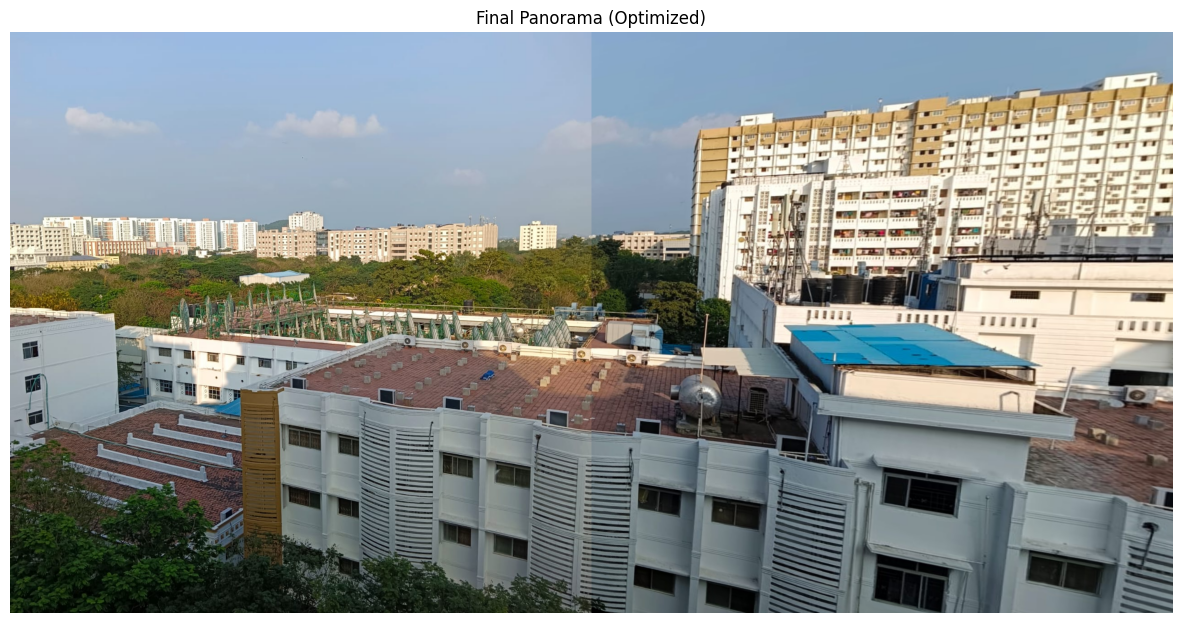

In [ ]:
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

panorama_width = w1 + w2
panorama_height = max(h1, h2)

warped_img2 = cv2.warpPerspective(img2, best_H, (panorama_width, panorama_height))
panorama = warped_img2.copy()
panorama[0:h1, 0:w1] = img1

plt.figure(figsize=(15, 10))
plt.imshow(panorama)
plt.title('Final Panorama (Optimized)')
plt.axis('off')
plt.show()